# Searchlight per-category specificity: v1 vs v2

Compares two ways of building **per-category** searchlight maps for the 4-class
stimulus-category problem (face / figure / hand / house), from GLMsingle type-D betas.
6 mm sphere, LinearSVC, leave-one-run-out CV.

| | **v1** (`searchlight/`) | **v2** (`searchlight_recall/`) |
|---|---|---|
| Per-category map | one-vs-rest **accuracy** | per-class **recall** from the competitive 4-way model |
| Class balance | 1:3 (imbalanced) | balanced 4-way (`class_weight='balanced'`) |
| Chance | **none fixed** — 0.25–0.75 depending on classifier bias (≈0.69 empirically) | **0.25** |
| Problem | accuracy on a 1:3 split has no well-defined chance and never reaches the 0.75 majority ceiling | reads as "how reliably a sphere identifies category *k* vs the other 3" |

**Why v2:** one-vs-rest accuracy on a 1:3 split has no usable chance level (Section 2), so
the v1 per-category maps can't be thresholded or tested cleanly. Per-class recall from the
single balanced 4-way model has a fixed analytic chance of 0.25. The overall 4-class map is
essentially unchanged between versions (only `class_weight` added — a near-no-op on the
balanced problem); Section 1 confirms this.

**Display principle:** v1 and v2 per-category maps have *different chance levels and value
ranges*, so we never share a raw color scale. v1 is referenced to its **empirical
whole-brain null**; v2 to its analytic chance 0.25. Valid inference (Section 4) is done on
v2 only.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from nilearn import image, plotting, datasets

sys.path.insert(0, str(Path('../')))
try:
    from utils.data import load_participant_list
except Exception:
    load_participant_list = None

# --- Auto-detect where the derivatives live (VM mount, else local sync) ---
_DERIV_CANDIDATES = [
    Path('/mnt/data/learning-habits/bids_dataset/derivatives'),                          # uzh.vm
    Path.home() / 'phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives',   # local Mac sync
]
DERIVATIVES_DIR = next((p for p in _DERIV_CANDIDATES if p.exists()), _DERIV_CANDIDATES[0])
print(f'DERIVATIVES_DIR = {DERIVATIVES_DIR}')
# --------------------------------------------------------------------------

SL_V1 = DERIVATIVES_DIR / 'searchlight'          # one-vs-rest accuracy, chance 0.75
SL_V2 = DERIVATIVES_DIR / 'searchlight_recall'   # per-class recall,      chance 0.25
VC_MASK_PATH = DERIVATIVES_DIR / 'decoding' / 'visual_cortex_mask.nii.gz'
FUSIFORM_MASK_PATH = DERIVATIVES_DIR.parent.parent / 'masks' / 'MNI152NLin2009cAsym' / 'fusiform_mask_MNI152NLin2009cAsym.nii'
PARTICIPANTS_FILE = DERIVATIVES_DIR.parent.parent / 'participants_mvpa.tsv'

STIM_CATS = ['face', 'figure', 'hand', 'house']
CHANCE_OVERALL = 0.25       # 4-class map (both versions)
CHANCE_V1 = 0.75            # v1 per-category: one-vs-rest accuracy floor
CHANCE_V2 = 0.25            # v2 per-category: per-class recall under 4-way null
ALPHA_FDR = 0.05

# v1/v2 per-category filename builders (they differ: v2 carries a `recall_` infix)
def v1_cat_path(sub, cat):
    return SL_V1 / f'sub-{sub}' / f'sub-{sub}_searchlight_stim_cat_{cat}.nii.gz'
def v2_cat_path(sub, cat):
    return SL_V2 / f'sub-{sub}' / f'sub-{sub}_searchlight_stim_cat_recall_{cat}.nii.gz'
def overall_path(root, sub):
    return root / f'sub-{sub}' / f'sub-{sub}_searchlight_stim_cat.nii.gz'

# Subject list: prefer the canonical TSV, else intersect what both versions produced
if load_participant_list is not None and PARTICIPANTS_FILE.exists():
    subjects = load_participant_list(PARTICIPANTS_FILE.parent, file_name=PARTICIPANTS_FILE.name)
else:
    v1_subs = {p.name[4:] for p in SL_V1.glob('sub-*') if p.is_dir()}
    v2_subs = {p.name[4:] for p in SL_V2.glob('sub-*') if p.is_dir()}
    subjects = sorted(v1_subs & v2_subs)
print(f'Candidate subjects: {len(subjects)}')

DERIVATIVES_DIR = /mnt/data/learning-habits/bids_dataset/derivatives
Candidate subjects: 59


## 0. Completeness & group mask

Keep only subjects that have **both** versions complete (overall map + all 4 per-category
maps in each). Build a single group brain mask (MNI152 resampled to the map grid) used for
all voxelwise stats. `concat_imgs` requires a common affine/shape — we guard the load loop
and report any offenders rather than letting a cell crash.

In [2]:
def complete(sub):
    ok = overall_path(SL_V1, sub).exists() and overall_path(SL_V2, sub).exists()
    ok &= all(v1_cat_path(sub, c).exists() for c in STIM_CATS)
    ok &= all(v2_cat_path(sub, c).exists() for c in STIM_CATS)
    return ok

subs = [s for s in subjects if complete(s)]
dropped = [s for s in subjects if s not in subs]
print(f'Subjects with BOTH versions complete: {len(subs)}')
if dropped:
    print(f'Dropped (incomplete in v1 and/or v2): {dropped}')

def load_4d(paths, ref_affine=None, ref_shape=None):
    """Load a list of NIfTI paths into a 4D image, guarding grid consistency."""
    imgs, bad = [], []
    for p in paths:
        img = nib.load(p)
        if ref_shape is None:
            ref_affine, ref_shape = img.affine, img.shape[:3]
        if img.shape[:3] != ref_shape or not np.allclose(img.affine, ref_affine, atol=1e-3):
            bad.append(Path(p).parent.name)
            continue
        imgs.append(img)
    if bad:
        print(f'  WARNING: {len(bad)} maps off-grid, skipped: {bad}')
    return image.concat_imgs(imgs), ref_affine, ref_shape

# Overall 4-class maps (v2) define the reference grid; assert v1 shares it per subject
ov2, aff, shp = load_4d([overall_path(SL_V2, s) for s in subs])
ov1, _, _     = load_4d([overall_path(SL_V1, s) for s in subs], aff, shp)
assert not np.isnan(ov2.get_fdata()).all(), 'v2 overall maps all-NaN?'
print(f'Overall 4D shapes  v1={ov1.shape}  v2={ov2.shape}')

# Group brain mask
mni_mask = datasets.load_mni152_brain_mask()
group_mask = image.resample_to_img(mni_mask, ov2, interpolation='nearest')
mask_data = group_mask.get_fdata().astype(bool)
print(f'Group brain mask: {mask_data.sum()} voxels')

def load_roi_mask(mask_path, ref_img, brain_mask):
    roi = image.resample_to_img(str(mask_path), ref_img, interpolation='nearest')
    return roi.get_fdata().astype(bool) & brain_mask

Subjects with BOTH versions complete: 59


Overall 4D shapes  v1=(53, 65, 48, 59)  v2=(53, 65, 48, 59)
Group brain mask: 59793 voxels


## 1. Overall 4-class map: v1 vs v2 (sanity)

The overall 4-class searchlight is the *same* analysis in both versions, differing only by
`class_weight='balanced'` — a near-no-op on the balanced 4-way problem. Per-subject
whole-brain mean accuracy should fall on the identity line. This validates the decision to
let v2 re-emit its own overall map rather than reuse v1's.

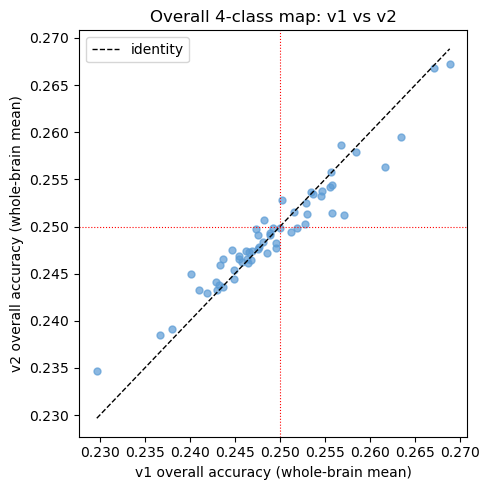

v2 - v1 overall whole-brain mean: +0.0001 ± 0.0020 (max |diff| = 0.0058)


In [3]:
ov1_mean = ov1.get_fdata()[mask_data, :].mean(axis=0)   # per-subject whole-brain mean
ov2_mean = ov2.get_fdata()[mask_data, :].mean(axis=0)

fig, ax = plt.subplots(figsize=(5, 5))
lo = min(ov1_mean.min(), ov2_mean.min()); hi = max(ov1_mean.max(), ov2_mean.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='identity')
ax.scatter(ov1_mean, ov2_mean, s=25, alpha=0.7, color='#5B9BD5')
ax.axvline(CHANCE_OVERALL, color='red', ls=':', lw=0.8)
ax.axhline(CHANCE_OVERALL, color='red', ls=':', lw=0.8)
ax.set_xlabel('v1 overall accuracy (whole-brain mean)')
ax.set_ylabel('v2 overall accuracy (whole-brain mean)')
ax.set_title('Overall 4-class map: v1 vs v2')
ax.legend()
plt.tight_layout(); plt.show()

d = ov2_mean - ov1_mean
print(f'v2 - v1 overall whole-brain mean: {d.mean():+.4f} ± {d.std():.4f} '
      f'(max |diff| = {np.abs(d).max():.4f})')

## 2. Per-category group-mean maps, side by side (native units)

**Why v1 needs a different reference than 0.75.** One-vs-rest *accuracy* has **no fixed
chance level**. Always predicting the majority class ("rest") scores 0.75 — but that's a
*ceiling* a real classifier rarely reaches, because the SVC also predicts the target class
some of the time, and every false positive costs accuracy. Depending on how trigger-happy
it is, null accuracy lands anywhere in **[0.25, 0.75]**:

| null strategy | predicts "target" | accuracy |
|---|---|---|
| always "rest" (majority ceiling) | 0% | 0.75 |
| guess at base rate (stratified dummy) | 25% | 0.625 |
| **our trained SVC on noise** | ~11% | **~0.69** |

So subtracting 0.75 as "chance" drives the whole map negative — not because there's no
signal, but because 0.75 is unreachable (this map maxes out at ~0.72). We instead reference
v1 to its **empirical whole-brain null**: the median accuracy across in-brain voxels, which
is dominated by non-informative voxels and so captures the SVC's *actual* bias per category
(no dummy or permutation rerun needed). v2 per-class recall keeps its clean analytic chance
of 0.25.

Below: v1 on its own empirical-null-anchored scale, v2 on its 0.25-anchored scale.

v1 one-vs-rest accuracy reference points:
  stratified-dummy null (base-rate guess): 0.625   [same for all cats]
  majority ceiling (always "rest")        : 0.750   [unreachable]
  face  : empirical null (WB median) = 0.695   brain max = 0.718  (never reaches 0.75)
  figure: empirical null (WB median) = 0.717   brain max = 0.755  (never reaches 0.75)
  hand  : empirical null (WB median) = 0.692   brain max = 0.713  (never reaches 0.75)
  house : empirical null (WB median) = 0.696   brain max = 0.719  (never reaches 0.75)


/tmp/ipykernel_62047/333284921.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


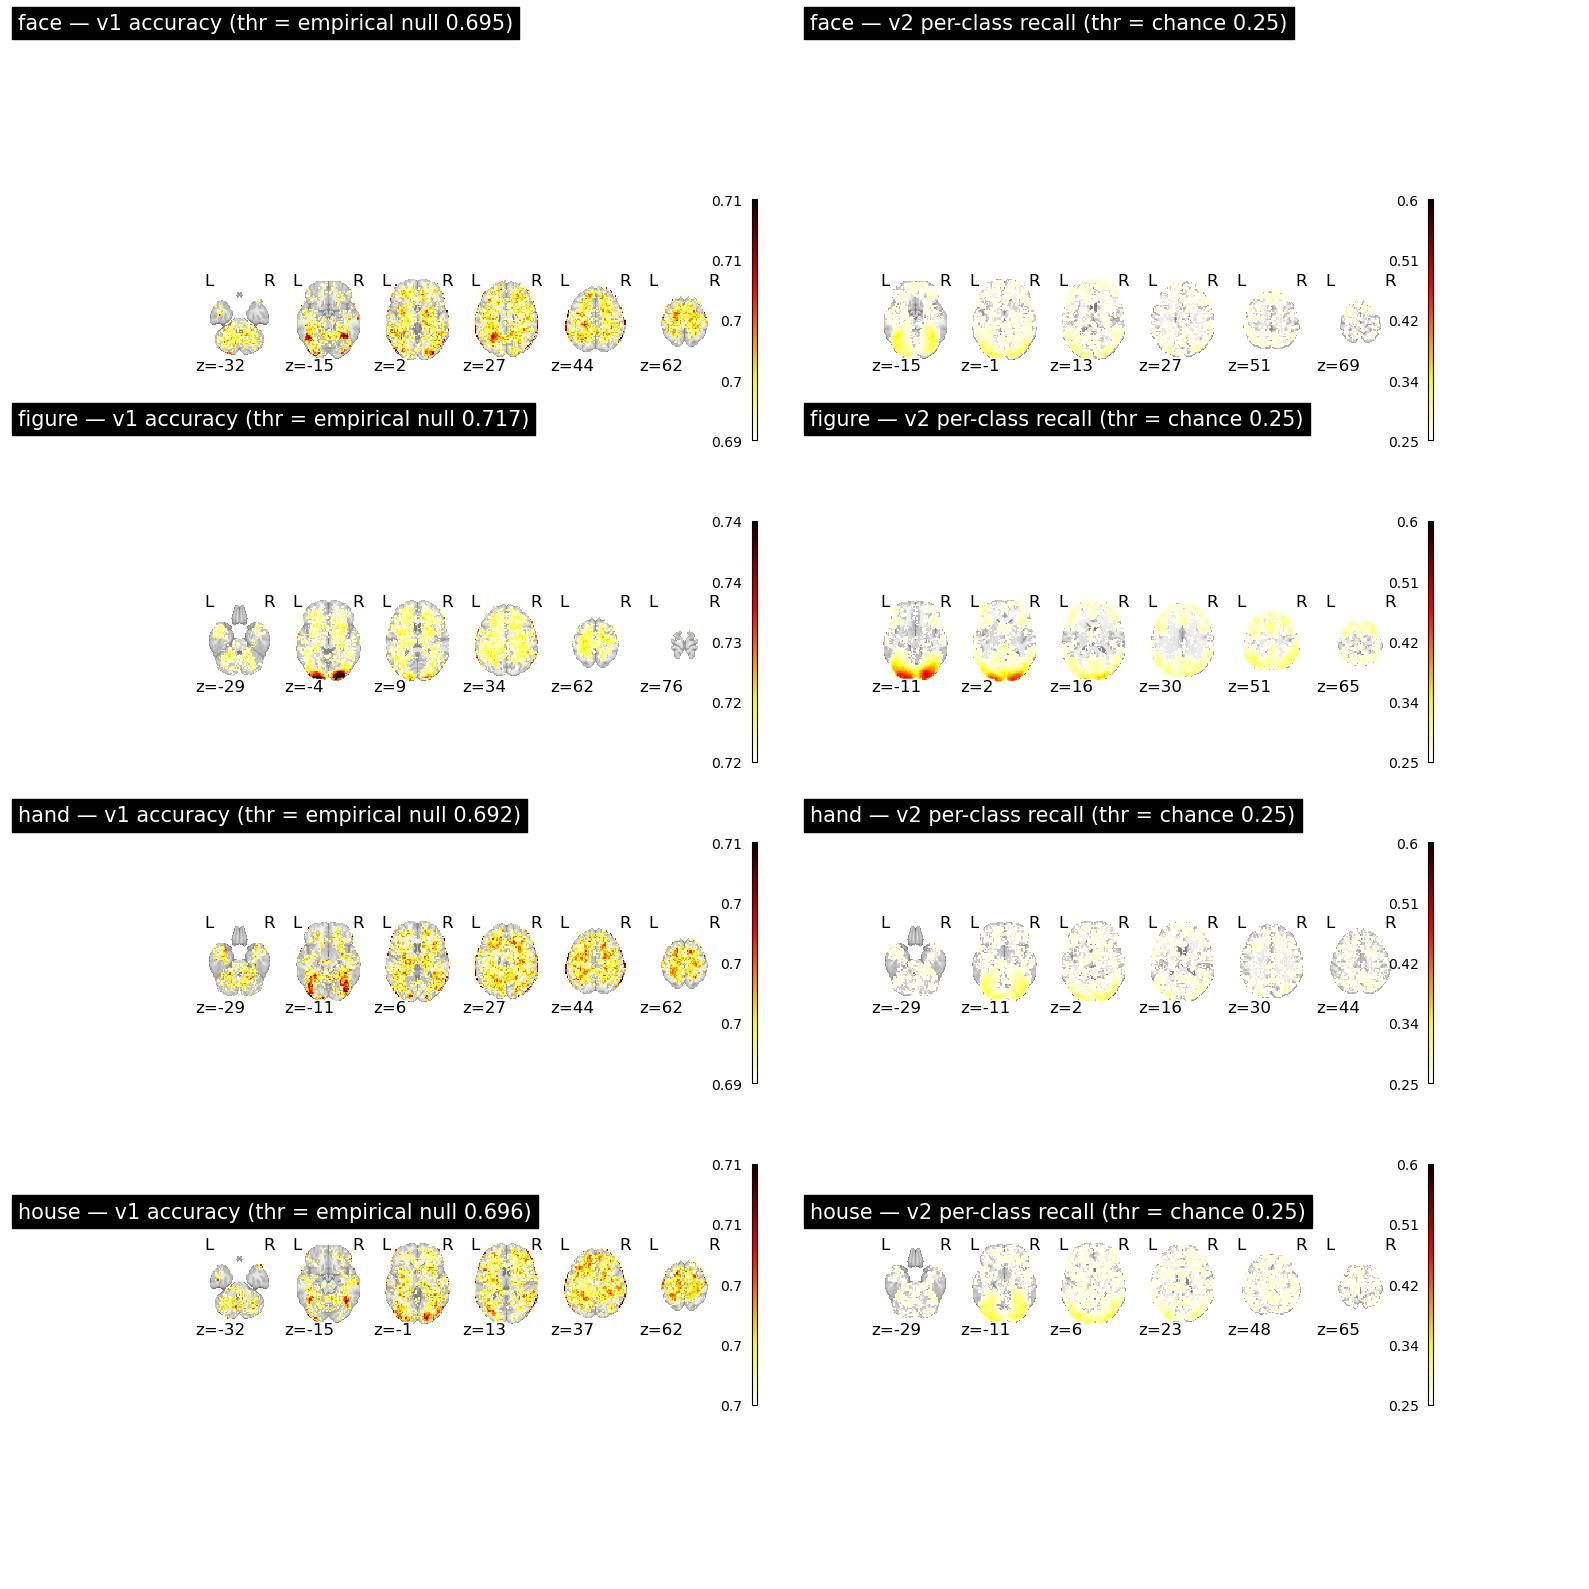

In [4]:
# Load all per-category maps into 4D (subjects along 4th dim), both versions
cat_v1, cat_v2 = {}, {}
for c in STIM_CATS:
    cat_v1[c], _, _ = load_4d([v1_cat_path(s, c) for s in subs], aff, shp)
    cat_v2[c], _, _ = load_4d([v2_cat_path(s, c) for s in subs], aff, shp)
mean_v1 = {c: image.mean_img(cat_v1[c]) for c in STIM_CATS}
mean_v2 = {c: image.mean_img(cat_v2[c]) for c in STIM_CATS}

# --- Empirical v1 null (see markdown) -------------------------------------
# One-vs-rest accuracy has no fixed analytic chance; the whole-brain median is
# dominated by non-informative voxels, so it estimates the SVC's actual null per
# category (captures its majority-bias) — unlike the 0.625 stratified-dummy
# baseline or the unreachable 0.75 majority ceiling.
EMP_NULL_V1 = {c: float(np.median(mean_v1[c].get_fdata()[mask_data])) for c in STIM_CATS}
print('v1 one-vs-rest accuracy reference points:')
print('  stratified-dummy null (base-rate guess): 0.625   [same for all cats]')
print('  majority ceiling (always "rest")        : 0.750   [unreachable]')
for c in STIM_CATS:
    mx = float(mean_v1[c].get_fdata()[mask_data].max())
    print(f'  {c:6s}: empirical null (WB median) = {EMP_NULL_V1[c]:.3f}   '
          f'brain max = {mx:.3f}  (never reaches 0.75)')

# Native maps: v1 relative to ITS empirical null (thresholding at 0.75 would blank
# the map — nothing reaches it); v2 relative to its analytic chance 0.25.
fig, axes = plt.subplots(len(STIM_CATS), 2, figsize=(16, 4 * len(STIM_CATS)))
for row, c in enumerate(STIM_CATS):
    v1hi = np.percentile(mean_v1[c].get_fdata()[mask_data], 99.9)
    plotting.plot_stat_map(mean_v1[c], threshold=EMP_NULL_V1[c], colorbar=True,
        title=f'{c} — v1 accuracy (thr = empirical null {EMP_NULL_V1[c]:.3f})',
        display_mode='z', cut_coords=6, axes=axes[row, 0],
        cmap='hot_r', vmin=EMP_NULL_V1[c], vmax=v1hi)
    plotting.plot_stat_map(mean_v2[c], threshold=CHANCE_V2, colorbar=True,
        title=f'{c} — v2 per-class recall (thr = chance 0.25)', display_mode='z',
        cut_coords=6, axes=axes[row, 1], cmap='hot_r', vmin=CHANCE_V2, vmax=0.60)
plt.tight_layout(); plt.show()

## 3. Null-corrected group means (shared scale) — headline comparison

v1 is corrected against its **empirical whole-brain null** (per category, from Section 2),
v2 against its **analytic chance 0.25**, so both center on 0 and share a diverging scale.
This is the fair side-by-side. Even with a fair null, v1 accuracy carries only a faint bump,
because the metric mixes sensitivity and specificity under the 1:3 imbalance; v2 recall is
sharper in category-selective cortex.

shared |Δ| cap (99th pct): 0.466


/tmp/ipykernel_62047/1050032320.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


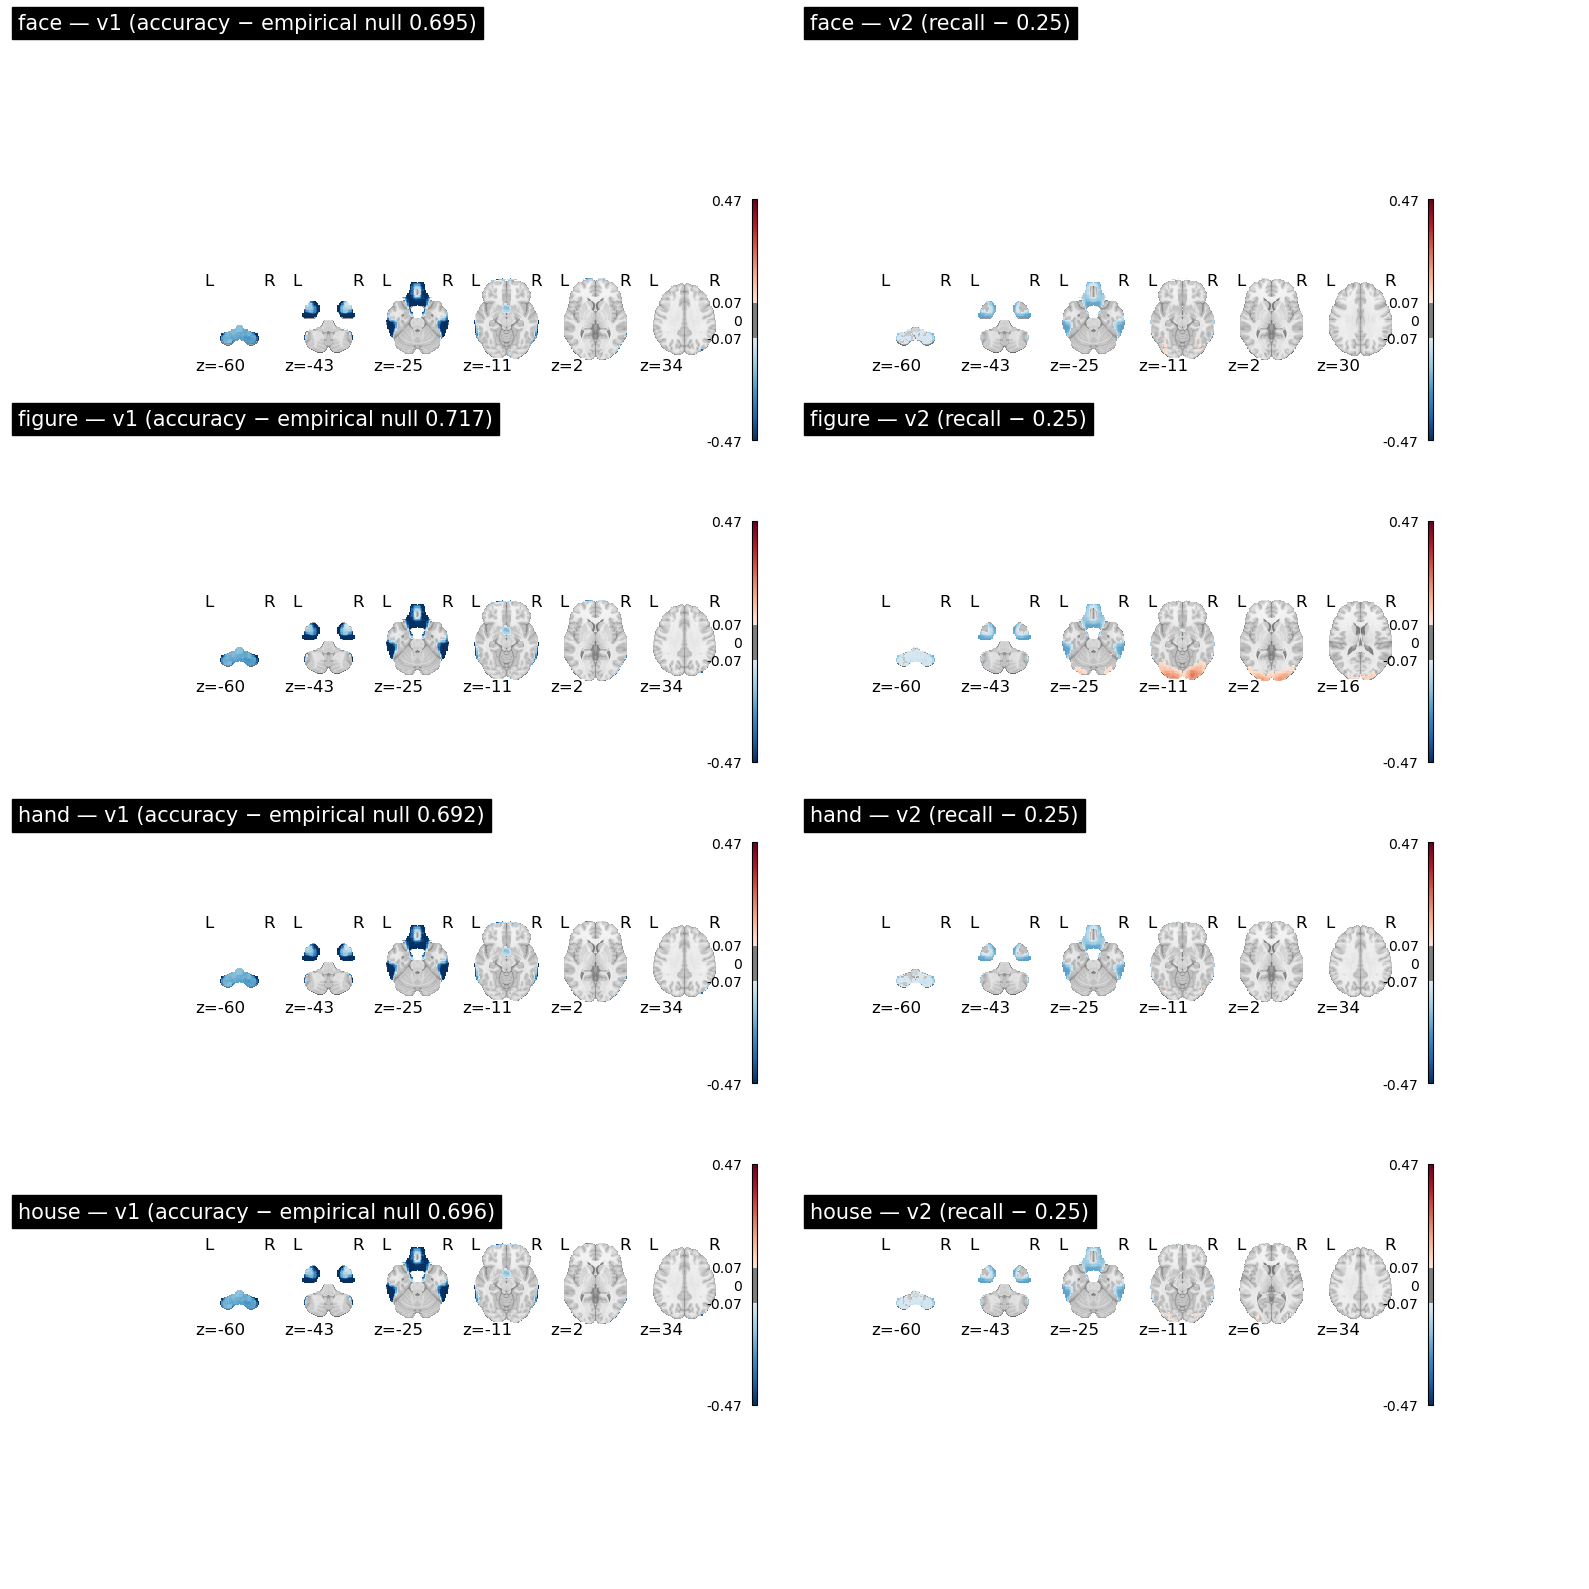

In [5]:
def null_corrected(mean_img, null):
    d = mean_img.get_fdata() - null
    d[~mask_data] = 0.0
    return image.new_img_like(mean_img, d)

# v1 corrected against its per-category EMPIRICAL null; v2 against analytic 0.25
cc_v1 = {c: null_corrected(mean_v1[c], EMP_NULL_V1[c]) for c in STIM_CATS}
cc_v2 = {c: null_corrected(mean_v2[c], CHANCE_V2) for c in STIM_CATS}

# Shared symmetric scale across BOTH versions and all categories
vmax = np.percentile(np.abs(np.concatenate(
    [cc_v1[c].get_fdata()[mask_data] for c in STIM_CATS] +
    [cc_v2[c].get_fdata()[mask_data] for c in STIM_CATS])), 99)
print(f'shared |Δ| cap (99th pct): {vmax:.3f}')

fig, axes = plt.subplots(len(STIM_CATS), 2, figsize=(16, 4 * len(STIM_CATS)))
for row, c in enumerate(STIM_CATS):
    plotting.plot_stat_map(cc_v1[c], threshold=vmax * 0.15, colorbar=True,
        title=f'{c} — v1 (accuracy − empirical null {EMP_NULL_V1[c]:.3f})',
        display_mode='z', cut_coords=6, axes=axes[row, 0],
        cmap='RdBu_r', symmetric_cbar=True, vmax=vmax)
    plotting.plot_stat_map(cc_v2[c], threshold=vmax * 0.15, colorbar=True,
        title=f'{c} — v2 (recall − 0.25)', display_mode='z', cut_coords=6,
        axes=axes[row, 1], cmap='RdBu_r', symmetric_cbar=True, vmax=vmax)
plt.tight_layout(); plt.show()

## 4. Per-category group inference, v1 vs v2

**Only v2 supports valid inference.** v2 per-class recall has a fixed chance (0.25), so a
one-sample t-test vs 0.25 is meaningful. v1 one-vs-rest accuracy does **not**: testing it
against 0.75 flags nearly the whole brain as "significant", but the table below splits that
by sign and shows the significant voxels are almost all *below* 0.75 — i.e. accuracy is
reliably **under** the majority ceiling, which is the imbalance artifact, not category
information. So we report the v1 split as a diagnostic and run the real FDR inference on v2
(per-class recall vs 0.25).

          v1 sig >0.75  v1 sig <0.75  v2 sig >0.25  v2 sig <0.25
category                                                        
face                 0         59658          3605          3394
figure               0         59406         12454          4643
hand                 0         59658          2299          3347
house                0         59658          4583          3512

v1: "significant" voxels are almost all BELOW 0.75 — accuracy sits reliably under the majority ceiling, i.e. the imbalance artifact, not above-chance decoding.
v2: significant voxels ABOVE 0.25 are genuine per-class decodability.


/tmp/ipykernel_62047/4121324116.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


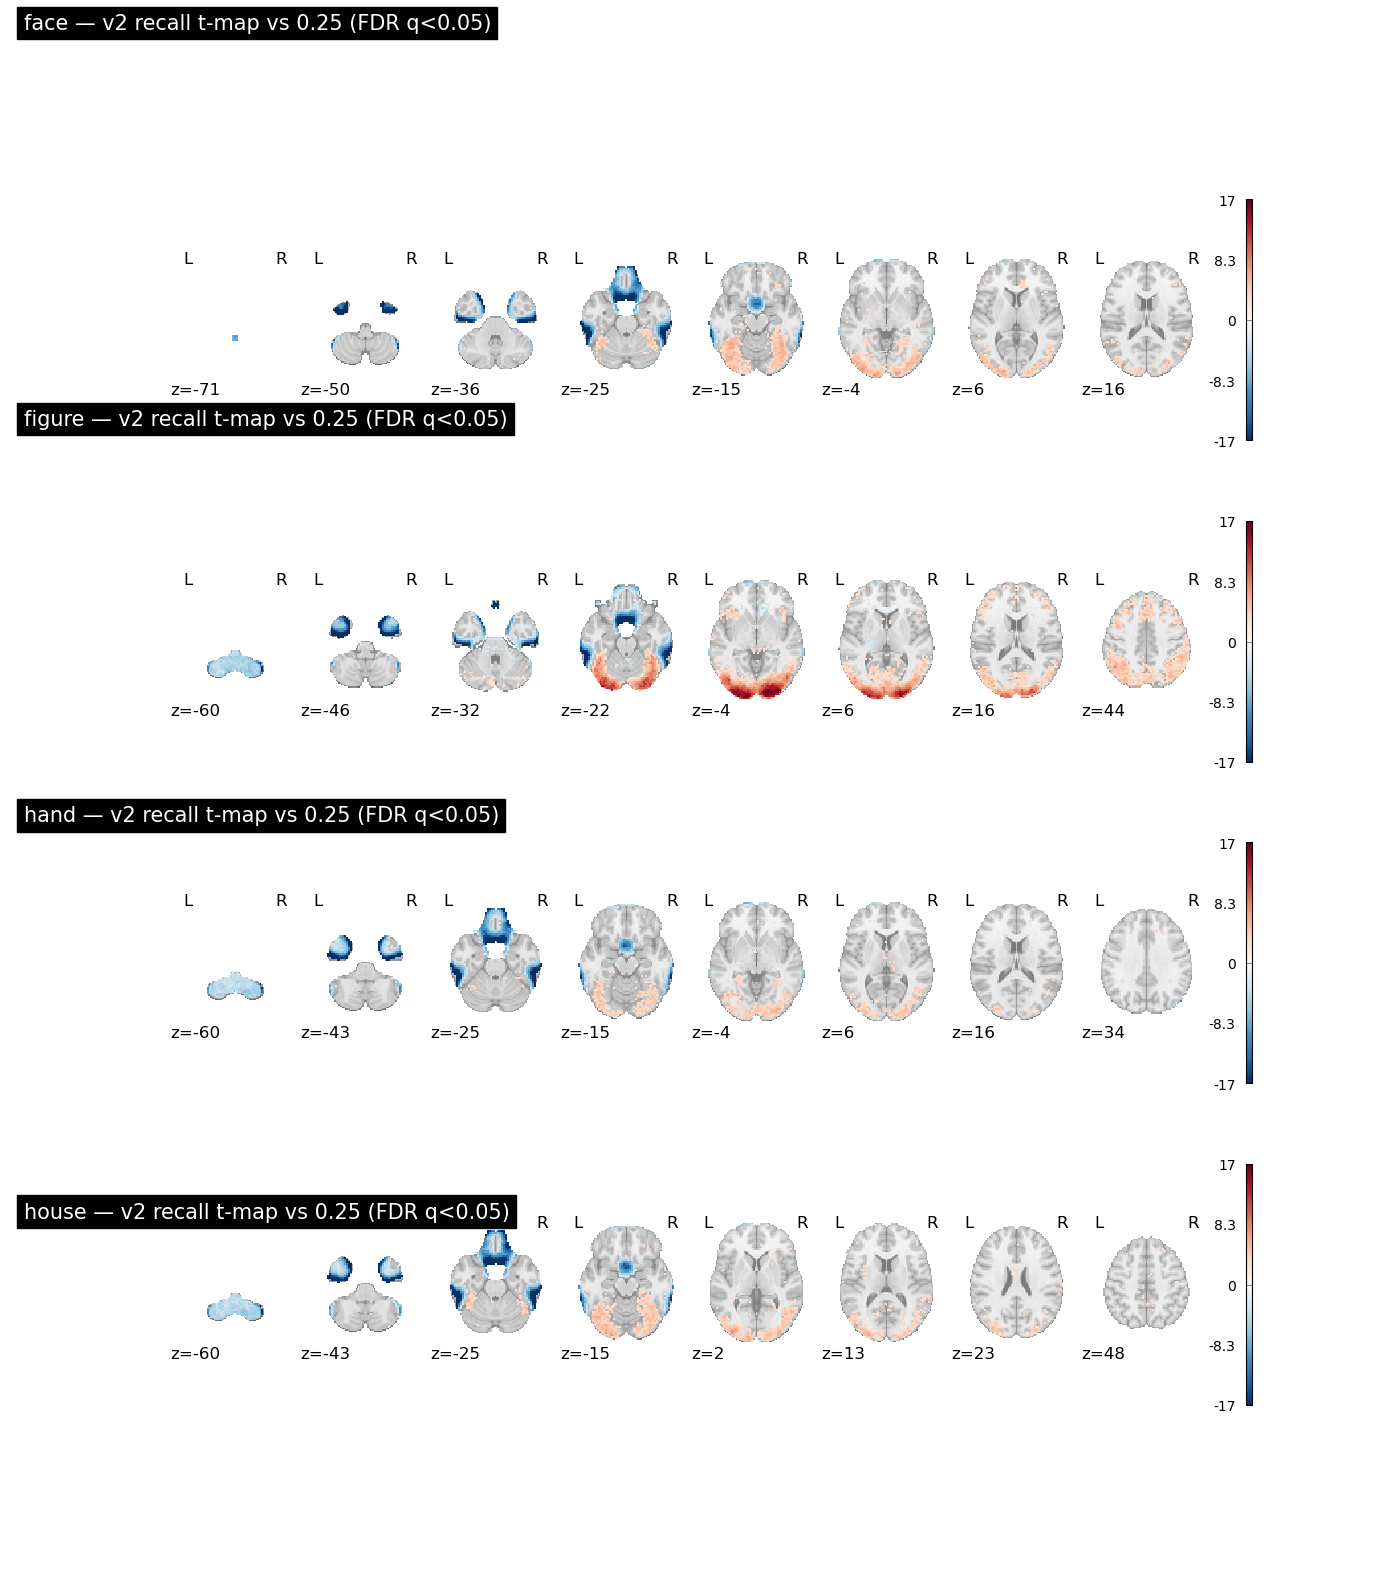

In [6]:
def fdr_tmap(img_4d, chance):
    """One-sample t vs `chance` at each voxel, FDR-corrected. Returns the signed
    t-map (significant voxels only) plus counts of sig voxels above/below chance."""
    data = img_4d.get_fdata()[mask_data, :].T          # (n_subjects, n_voxels)
    t, p = stats.ttest_1samp(data, popmean=chance, axis=0)
    t = np.nan_to_num(t, nan=0.0, posinf=0.0, neginf=0.0)
    p = np.nan_to_num(p, nan=1.0, posinf=1.0, neginf=1.0)
    _, q = fdrcorrection(p, alpha=ALPHA_FDR)
    sig = np.zeros(mask_data.shape)
    sig[mask_data] = np.where(q < ALPHA_FDR, t, 0.0)
    above = int(((q < ALPHA_FDR) & (t > 0)).sum())
    below = int(((q < ALPHA_FDR) & (t < 0)).sum())
    return image.new_img_like(group_mask, sig), above, below

# v1 tested vs its NOMINAL 0.75 (to expose the artifact); v2 vs analytic 0.25.
sig_v2, rows = {}, []
for c in STIM_CATS:
    _, v1_above, v1_below = fdr_tmap(cat_v1[c], CHANCE_V1)          # vs 0.75
    sig_v2[c], v2_above, v2_below = fdr_tmap(cat_v2[c], CHANCE_V2)  # vs 0.25
    rows.append({'category': c,
                 'v1 sig >0.75': v1_above, 'v1 sig <0.75': v1_below,
                 'v2 sig >0.25': v2_above, 'v2 sig <0.25': v2_below})
sig_table = pd.DataFrame(rows).set_index('category')
print(sig_table)
print('\nv1: "significant" voxels are almost all BELOW 0.75 — accuracy sits reliably under '
      'the majority ceiling, i.e. the imbalance artifact, not above-chance decoding.')
print('v2: significant voxels ABOVE 0.25 are genuine per-class decodability.')

# Valid inference = v2 (per-class recall vs 0.25).
tmax = np.percentile(np.abs(np.concatenate(
    [sig_v2[c].get_fdata()[mask_data] for c in STIM_CATS])), 99) or 1.0
fig, axes = plt.subplots(len(STIM_CATS), 1, figsize=(14, 4 * len(STIM_CATS)))
for ax, c in zip(axes, STIM_CATS):
    plotting.plot_stat_map(sig_v2[c], threshold=0.1, colorbar=True,
        title=f'{c} — v2 recall t-map vs 0.25 (FDR q<{ALPHA_FDR})',
        display_mode='z', cut_coords=8, axes=ax,
        cmap='RdBu_r', symmetric_cbar=True, vmax=tmax)
plt.tight_layout(); plt.show()

## 5. ROI summary, v1 vs v2

Mean per-category value within visual cortex and fusiform ROIs. **v1** is referenced to each
subject's **empirical whole-brain null** (its own median accuracy per category), **v2** to
its analytic chance 0.25 — so a single `y = 0` baseline serves both. Bars are group
mean ± SEM of the per-subject (null-corrected) ROI means; stars are one-sample t vs 0.
v1 here is descriptive only (its null is data-derived); v2 supports the actual inference.

Visual cortex: 7658 voxels
Fusiform: 320 voxels


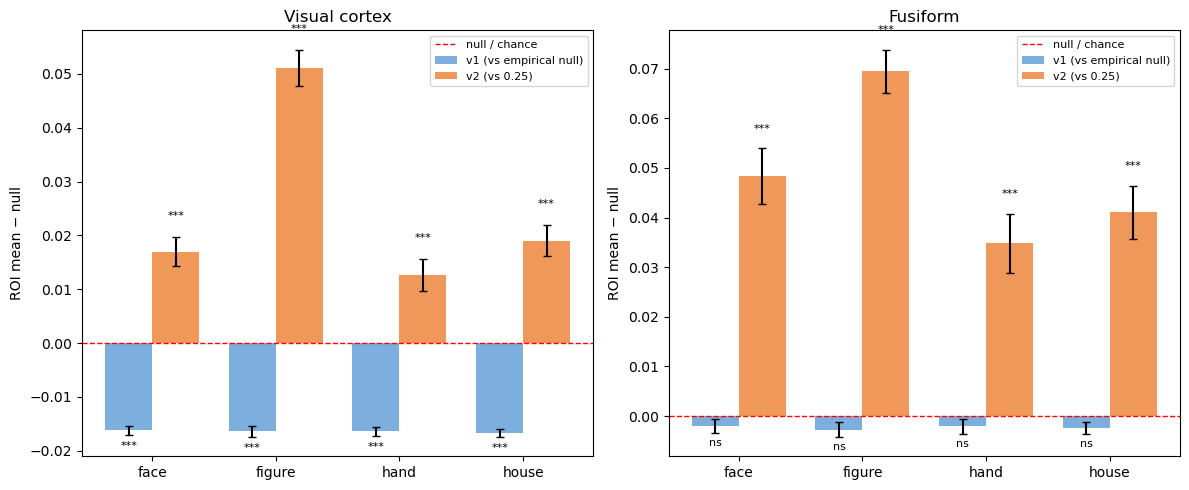

In [7]:
roi_masks = {}
for label, path in [('Visual cortex', VC_MASK_PATH), ('Fusiform', FUSIFORM_MASK_PATH)]:
    if Path(path).exists():
        roi_masks[label] = load_roi_mask(path, group_mask, mask_data)
        print(f'{label}: {roi_masks[label].sum()} voxels')
    else:
        print(f'{label}: mask not found at {path} — skipping')

def star(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else 'ns'

# Per-subject empirical v1 null = each subject's whole-brain median (per category)
subj_null_v1 = {c: np.median(cat_v1[c].get_fdata()[mask_data, :], axis=0) for c in STIM_CATS}

# (version label, 4D maps, per-subject baseline array-or-scalar, colour)
series = [
    ('v1 (vs empirical null)', cat_v1, subj_null_v1, '#5B9BD5'),
    ('v2 (vs 0.25)',           cat_v2, None,         '#ED7D31'),
]

fig, axes = plt.subplots(1, len(roi_masks), figsize=(6 * len(roi_masks), 5), squeeze=False)
x = np.arange(len(STIM_CATS)); w = 0.38
for col, (label, rmask) in enumerate(roi_masks.items()):
    ax = axes[0, col]
    for off, (ver, cats, null, color) in enumerate(series):
        means, sems = [], []
        for i, c in enumerate(STIM_CATS):
            roi_mean = cats[c].get_fdata()[rmask, :].mean(axis=0)       # per-subject ROI mean
            base = null[c] if null is not None else CHANCE_V2           # per-subject null or 0.25
            vals = roi_mean - base
            means.append(vals.mean()); sems.append(vals.std() / np.sqrt(len(vals)))
            _, p = stats.ttest_1samp(vals, 0.0)
            ax.text(i + (off - 0.5) * w, vals.mean() + np.sign(vals.mean() or 1) * (sems[-1] + 0.003),
                    star(p), ha='center', va='bottom', fontsize=8)
        ax.bar(x + (off - 0.5) * w, means, w, yerr=sems, capsize=3, alpha=0.8,
               color=color, label=ver)
    ax.axhline(0, color='red', ls='--', lw=1, label='null / chance')
    ax.set_xticks(x); ax.set_xticklabels(STIM_CATS)
    ax.set_title(label); ax.set_ylabel('ROI mean − null')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Findings summary

- **Overall map (Sec 1):** v1 and v2 whole-brain 4-class accuracy fall on the identity line
  (mean diff ≈ +0.0001) → `class_weight='balanced'` is a no-op; the re-emitted v2 overall
  map is equivalent to v1's.
- **v1 one-vs-rest accuracy is not a usable metric (Sec 2–4):** it never reaches its nominal
  0.75 "chance" (brain max ≈ 0.72), sits ~0.05 below it brain-wide, and has **no fixed
  chance level** — the null lands anywhere in [0.25, 0.75] depending on the classifier's
  bias (~0.69 empirically). Referenced to a fair empirical null it shows only a faint
  category bump. Its apparent "whole-brain significance vs 0.75" is significance *below*
  0.75 (the Sec 4 sign split), i.e. an imbalance artifact, not decoding.
- **v2 per-class recall works (Sec 3–5):** clean analytic chance 0.25, focal above-chance
  recall in category-selective cortex, and it supports valid FDR inference (Sec 4) and ROI
  contrasts (Sec 5).
- **Bottom line:** the v1→v2 change is not cosmetic. One-vs-rest accuracy is fundamentally
  miscalibrated on this 1:3 problem; per-class recall (Fix B) is the correct metric, and
  the substantive per-category localization comes from v2.